# Crawling & Analisis Data Polutan Udara di Kecamatan Gresik

**Nama:** Ahmad Syahrul Farihin

**NIM:** 240411100031

**Mata Kuliah:** Pengantar Sains Data (PSD) - B

Notebook ini membahas enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, CH4) di wilayah Kecamatan Gresik menggunakan data satelit Sentinel-5P. Pembahasan dibatasi hingga tahap **Business Understanding** dan **Data Understanding**, ditutup dengan grafik time series.

## 1. Business Understanding

### 1.1 Latar Belakang

Kecamatan Gresik merupakan salah satu wilayah perkotaan di Kabupaten Gresik yang memiliki aktivitas permukiman, perdagangan, jasa, industri, serta lalu lintas kendaraan yang cukup tinggi. Wilayah di sekitar Kecamatan Gresik juga dipengaruhi oleh keberadaan berbagai kegiatan industri, seperti industri semen, pupuk/petrokimia, pengolahan logam, dan pengolahan minyak nabati, serta jalur transportasi yang cukup padat. Kombinasi aktivitas tersebut berpotensi menjadi sumber berbagai gas pencemar udara. Pemantauan kualitas udara di wilayah semacam ini penting dilakukan karena sumber pencemarannya dapat berasal dari beberapa sektor sekaligus, seperti industri, transportasi, maupun aktivitas masyarakat.

### 1.2 Tujuan

- Mengumpulkan data enam polutan udara (CO, NO2, HCHO, O3, SO2, CH4) di wilayah Kecamatan Gresik selama periode minimal satu tahun sebelum 31 Agustus 2026.
- Mengamati perubahan konsentrasi tiap polutan dari waktu ke waktu melalui grafik time series.
- Mengidentifikasi kemungkinan sumber emisi masing-masing polutan berdasarkan karakteristik wilayah Kecamatan Gresik.
- Melakukan Data Understanding: memeriksa struktur data, missing value, dan outlier/data aneh.

### 1.3 Manfaat

Hasil analisis ini diharapkan dapat memberikan gambaran awal mengenai kondisi kualitas udara di Kecamatan Gresik serta pola konsentrasi tiap polutan sepanjang waktu, sekaligus menjadi landasan bagi tahap preprocessing dan pemodelan pada pertemuan berikutnya.

### 1.4 Penjelasan dan Kemungkinan Sumber Tiap Polutan

| Polutan | Apa Itu? | Kemungkinan Sumber |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tidak berwarna dan tidak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna. Berikatan dengan hemoglobin lebih kuat daripada oksigen sehingga berbahaya bagi pernapasan. | Emisi kendaraan bermotor, pembakaran biomassa/lahan, aktivitas industri dengan proses pembakaran |
| **NO2** (Nitrogen Dioksida) | Gas hasil pembakaran suhu tinggi, berperan dalam pembentukan hujan asam dan ozon permukaan. | Emisi kendaraan bermotor, pembangkit listrik, dan aktivitas industri |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC), sering dipakai sebagai indikator tidak langsung emisi VOC di atmosfer. | Aktivitas industri, pembakaran biomassa, emisi kendaraan, dan oksidasi VOC dari vegetasi |
| **O3** (Ozon Troposferik) | Bukan gas yang diemisikan langsung, melainkan polutan sekunder hasil reaksi fotokimia NOx dan VOC dengan bantuan sinar matahari. | Reaksi emisi kendaraan dan aktivitas industri (NOx, VOC) dengan sinar matahari |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung sulfur. | Aktivitas industri dan pembakaran bahan bakar yang mengandung sulfur |
| **CH4** (Metana) | Gas rumah kaca dengan efek pemanasan jauh lebih kuat dari CO2. | TPA sampah, lahan persawahan, peternakan, kebocoran gas alam, dan aktivitas industri |

### 1.5 Deskripsi Data

- **Sumber data:** Sentinel-5P TROPOMI (koleksi `SENTINEL_5P_L2`), diakses lewat `openeo` pada Copernicus Data Space Ecosystem.
- **Cakupan wilayah:** Kecamatan Gresik, dibatasi menggunakan polygon GeoJSON berdasarkan wilayah kecamatan.
- **Periode target:** minimal satu tahun hingga 31 Agustus 2026.
- **Satuan:** CO, NO2, HCHO, O3, dan SO2 dilaporkan sebagai kolom vertikal dalam **mol/m²**, sedangkan **CH4 dilaporkan dalam ppb** (*dry-air column-averaged mixing ratio*) - bukan mol/m² - sehingga skalanya jauh lebih besar (ribuan) dan tidak bisa dibandingkan langsung dengan polutan lain tanpa normalisasi.
- **Keluaran:** satu berkas `.csv` berisi kolom `date` serta enam kolom polutan.

## 2. Data Understanding

### 2.1 Wilayah Kajian (Area of Interest)

Batas wilayah kajian dibuat sebagai polygon GeoJSON melalui geojson.io, mencakup wilayah Kecamatan Gresik. Polygon ini kemudian dibaca ulang di Python untuk dihitung bounding box-nya, yang menjadi acuan spasial pada saat data ditarik dari server Copernicus.

In [1]:
!pip install openeo netCDF4 numpy pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.6 MB/s eta 0:00:00


In [2]:
import json
import openeo
import netCDF4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Penjelasan kode:** Seluruh pustaka yang dipakai sepanjang notebook (untuk membaca/menulis GeoJSON, mengambil data satelit, membaca berkas NetCDF, mengolah tabel, dan membuat grafik) diimpor sekaligus di sini agar tidak berulang-ulang di tiap bagian.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving gresik.geojson to gresik.geojson


**Penjelasan kode:** `files.upload()` digunakan untuk menampilkan pilihan file pada Google Colab sehingga pengguna dapat mengunggah file dari perangkat. Hasil proses upload kemudian disimpan ke dalam variabel `uploaded`, yang berisi informasi mengenai file yang berhasil diunggah dan dapat digunakan pada proses selanjutnya.

In [5]:
import json

# Membaca file GeoJSON wilayah Gresik
with open("gresik.geojson", "r", encoding="utf-8") as f:
    geojson_gresik = json.load(f)

# Mengambil geometry dari GeoJSON
aoi_gresik = geojson_gresik["features"][0]["geometry"]

# Mengambil seluruh koordinat, termasuk jika geometry berupa MultiPolygon
def ambil_titik(koordinat):
    if isinstance(koordinat[0], (int, float)):
        yield koordinat
    else:
        for bagian in koordinat:
            yield from ambil_titik(bagian)

titik_polygon = list(ambil_titik(aoi_gresik["coordinates"]))

# Mengambil longitude dan latitude
lon_list = [p[0] for p in titik_polygon]
lat_list = [p[1] for p in titik_polygon]

# Membuat bounding box
bbox = {
    "west": min(lon_list),
    "south": min(lat_list),
    "east": max(lon_list),
    "north": max(lat_list)
}

print("Tipe geometry:", aoi_gresik["type"])
print("Jumlah titik:", len(titik_polygon))
print("Bounding box wilayah Gresik:", bbox)

Tipe geometry: MultiPolygon
Jumlah titik: 2059
Bounding box wilayah Gresik: {'west': 112.628818631, 'south': -7.17838952399995, 'east': 112.674669144, 'north': -7.14541925799995}


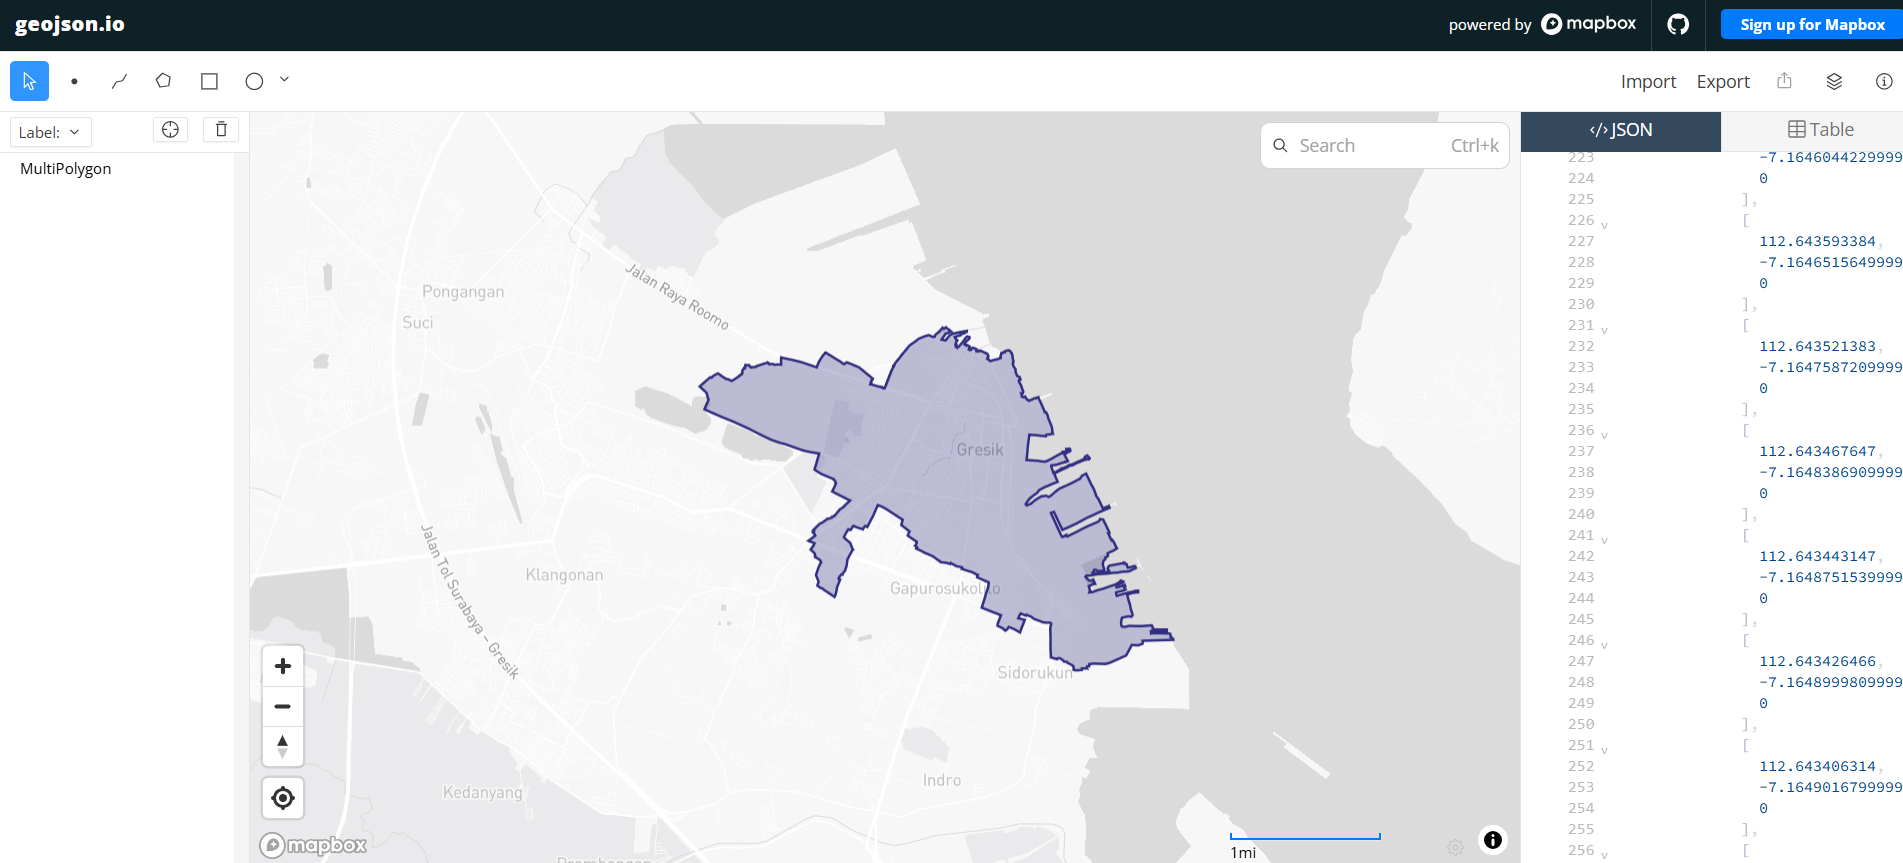

**Penjelasan kode:** `json` digunakan untuk membaca dan mengolah data dalam format GeoJSON. File `gresik.geojson` dibuka menggunakan `open()` kemudian dibaca dengan `json.load()`. Selanjutnya, bagian `geometry` diambil sebagai `aoi_gresik` untuk memperoleh bentuk wilayah beserta seluruh koordinatnya. Fungsi `ambil_titik()` digunakan untuk mengambil seluruh titik koordinat secara otomatis, termasuk apabila bentuk wilayah berupa `MultiPolygon`. Longitude dan latitude dari setiap titik kemudian dipisahkan untuk menentukan nilai batas wilayah. Nilai tersebut digunakan untuk membuat `bbox` yang terdiri dari batas barat, selatan, timur, dan utara. Terakhir, kode menampilkan tipe geometri, jumlah titik koordinat, dan bounding box wilayah Gresik.

### 2.2 Pengumpulan Data (Crawling)

Selanjutnya dibuat koneksi ke Copernicus Data Space Ecosystem (library pendukung sudah diinstal dan diimpor di bagian awal notebook).

In [6]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=DZVB-TNKX 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


**Penjelasan kode:** `openeo.connect(...)` membuka koneksi ke server Copernicus Data Space Ecosystem, sedangkan `.authenticate_oidc()` menjalankan proses login (akan muncul tautan autentikasi yang perlu dibuka dan di-login memakai akun Copernicus). Objek `connection` inilah yang dipakai pada semua permintaan data selanjutnya.


Perlu diperhatikan bahwa satu permintaan `load_collection` pada koleksi `SENTINEL_5P_L2` hanya dapat memuat **satu band/polutan**. Oleh sebab itu, dibuat dua fungsi bantu: satu untuk mengambil dan mengunduh data satu polutan, satu lagi untuk membaca hasil unduhan tersebut dan mengubahnya menjadi tabel harian. Kedua fungsi ini dipanggil berulang untuk keenam polutan.

In [7]:
daftar_polutan = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

tanggal_mulai = "2025-08-31"
tanggal_akhir = "2026-09-01"


def ambil_dan_unduh(kode_polutan):
    # Menarik satu jenis polutan dari SENTINEL_5P_L2 dan menyimpannya sebagai NetCDF.
    kubus = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[tanggal_mulai, tanggal_akhir],
        spatial_extent=bbox,
        bands=[kode_polutan],
    )
    kubus_harian = kubus.aggregate_temporal_period(reducer="mean", period="day")

    nama_file = f"{kode_polutan}_Gresik.nc"
    kubus_harian.execute_batch(title=f"Data {kode_polutan} Gresik", outputfile=nama_file)
    return nama_file

**Penjelasan kode:** `ambil_dan_unduh()` menyusun permintaan data ke koleksi `SENTINEL_5P_L2` untuk satu polutan (`kode_polutan`), dibatasi rentang waktu (`tanggal_mulai`–`tanggal_akhir`) dan wilayah (`bbox`). `aggregate_temporal_period(reducer="mean", period="day")` meringkas data menjadi satu nilai per hari, lalu `execute_batch(...)` menjalankan proses tersebut di server dan mengunduh hasilnya sebagai berkas NetCDF (`.nc`).

In [8]:
def rangkum_harian(kode_polutan, nama_file):
    #Membaca NetCDF hasil unduhan, lalu meringkas nilai per hari.

    ds = netCDF4.Dataset(nama_file)

    array_nilai = ds.variables[kode_polutan][:]
    waktu = ds.variables["t"]

    daftar_tanggal = netCDF4.num2date(
        waktu[:],
        units=waktu.units
    )

    rata_harian = []

    for i in range(len(daftar_tanggal)):
        nilai = np.ma.mean(array_nilai[i])

        # Jika nilainya masked, ubah menjadi NaN
        if np.ma.is_masked(nilai):
            rata_harian.append(np.nan)
        else:
            rata_harian.append(float(nilai))

    return pd.DataFrame({
        "date": [t.strftime("%Y-%m-%d") for t in daftar_tanggal],
        kode_polutan: rata_harian
    })

**Penjelasan kode:** `rangkum_harian()` membuka berkas NetCDF hasil `ambil_dan_unduh()`, mengambil array nilai polutan (berdimensi waktu × baris grid × kolom grid) beserta informasi waktunya, lalu mengonversi waktu tersebut menjadi tanggal dengan `netCDF4.num2date()`. Untuk tiap hari, seluruh nilai pada grid dirata-ratakan memakai `np.ma.mean()`, yang otomatis mengabaikan piksel bernilai kosong/masked (misalnya akibat tutupan awan). Hasil akhirnya berupa tabel dua kolom: tanggal dan nilai rata-rata polutan.

Selanjutnya, kedua fungsi tersebut dipanggil untuk tiap polutan, dan hasilnya digabungkan menjadi satu tabel berdasarkan kolom `date`.

In [9]:
tabel_gabungan = None

for kode in daftar_polutan:
    print(f"Memproses polutan {kode} ...")
    file_nc = ambil_dan_unduh(kode)
    tabel_polutan = rangkum_harian(kode, file_nc)

    if tabel_gabungan is None:
        tabel_gabungan = tabel_polutan
    else:
        tabel_gabungan = tabel_gabungan.merge(tabel_polutan, on="date", how="outer")

tabel_gabungan["date"] = pd.to_datetime(tabel_gabungan["date"])
tabel_gabungan = tabel_gabungan.sort_values("date").reset_index(drop=True)
tabel_gabungan.to_csv("polutan_gresik_timeseries.csv", index=False, na_rep="")

print("\nData berhasil disimpan!")
print("Tanggal pertama :", tabel_gabungan["date"].min().date())
print("Tanggal terakhir:", tabel_gabungan["date"].max().date())
print("Jumlah baris    :", len(tabel_gabungan))

Memproses polutan CO ...
0:00:00 Job 'j-2609120729074e9a8a90ec0dac9373c4': send 'start'
0:00:04 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:00:10 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:00:16 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:00:24 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:00:34 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:00:47 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:01:03 Job 'j-2609120729074e9a8a90ec0dac9373c4': queued (progress 0%)
0:01:22 Job 'j-2609120729074e9a8a90ec0dac9373c4': running (progress N/A)
0:01:46 Job 'j-2609120729074e9a8a90ec0dac9373c4': running (progress N/A)
0:02:17 Job 'j-2609120729074e9a8a90ec0dac9373c4': running (progress N/A)
0:02:54 Job 'j-2609120729074e9a8a90ec0dac9373c4': running (progress N/A)
0:03:41 Job 'j-2609120729074e9a8a90ec0dac9373c4': running (progress N/A)
0:04:40 Job 'j-2609120729074e9a8a90ec0dac9373c4': 

**Penjelasan kode:** Perulangan `for kode in daftar_polutan` memanggil `ambil_dan_unduh()` dan `rangkum_harian()` untuk tiap polutan secara berurutan, lalu hasil tiap polutan digabungkan ke `tabel_gabungan` berdasarkan kolom `date` memakai `merge(..., how="outer")` — opsi `outer` dipakai agar tanggal yang datanya kosong pada salah satu polutan tetap tersimpan sebagai `NaN`, bukan ikut terhapus dari tabel. Tabel akhir kemudian diurutkan berdasarkan tanggal dan disimpan ke `polutan_gresik_timeseries.csv`.

### 2.3 Struktur dan Isi Data

Mulai bagian ini, data dibaca kembali dari berkas CSV yang sudah tersimpan, sehingga proses eksplorasi berikutnya tidak perlu mengulang crawling dari awal.

In [10]:
df = pd.read_csv("polutan_gresik_timeseries.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Jumlah baris :", len(df))
print("Kolom        :", list(df.columns))
print("Rentang tgl  :", df["date"].min().date(), "s.d.", df["date"].max().date())
print()
df.info()

Jumlah baris : 366
Kolom        : ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']
Rentang tgl  : 2025-08-31 s.d. 2026-08-31

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[ns]
 1   CO      208 non-null    float64       
 2   NO2     188 non-null    float64       
 3   HCHO    232 non-null    float64       
 4   O3      362 non-null    float64       
 5   SO2     219 non-null    float64       
 6   CH4     29 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB


In [11]:
df.head()

,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.027550,0.000024,0.000145,0.116252,0.000210,NaN
1,2025-09-01,0.023488,0.000045,0.000042,0.114932,0.000058,NaN
2,2025-09-02,0.025977,0.000028,0.000089,0.115227,0.000534,NaN
3,2025-09-03,0.026092,0.000033,0.000225,0.113764,-0.000142,NaN
4,2025-09-04,0.029989,0.000060,0.000133,0.113487,0.000649,NaN


**Penjelasan kode:** `pd.read_csv(...)` membaca kembali berkas CSV hasil crawling, dengan `parse_dates=["date"]` agar kolom tanggal langsung terbaca sebagai tipe datetime, bukan teks. `df.info()` menampilkan tipe data tiap kolom serta jumlah nilai yang terisi, sedangkan `df.head()` menampilkan beberapa baris pertama untuk memeriksa apakah hasil crawling sudah sesuai format yang diharapkan.

 ### 2.4 Statistik Deskriptif

In [12]:
df[daftar_polutan].describe()

,CO,NO2,HCHO,O3,SO2,CH4
count,208.000000,188.000000,232.000000,362.000000,219.000000,29.000000
mean,0.029225,0.000072,0.000156,0.115857,0.000117,1893.185256
std,0.004243,0.000071,0.000133,0.002504,0.000311,19.593204
min,0.011331,0.000008,-0.000284,0.110287,-0.001086,1854.823608
25%,0.026602,0.000043,0.000070,0.114054,-0.000072,1887.126831
50%,0.029083,0.000057,0.000154,0.115825,0.000096,1897.868042
75%,0.031449,0.000077,0.000248,0.117421,0.000295,1906.232300
max,0.046535,0.000706,0.000584,0.123176,0.000964,1923.131348


**Penjelasan kode:** `describe()` menghitung ringkasan statistik (jumlah data valid, rata-rata, standar deviasi, nilai minimum-maksimum, serta kuartil) untuk tiap kolom polutan sekaligus, sehingga sebaran nilai keenam polutan bisa dibandingkan dalam satu tabel.

Terlihat perbedaan skala yang cukup jauh antarpolutan, terutama CH4 yang berada pada orde ribuan sementara polutan lain berada pada orde 10⁻⁵ hingga 10⁻¹. Hal ini konsisten dengan catatan pada bagian Deskripsi Data sebelumnya, bahwa CH4 memakai satuan ppb, bukan mol/m² seperti polutan lainnya.

### 2.5 Missing Value

Missing value pada data Sentinel-5P umumnya muncul akibat tutupan awan, kualitas retrieval yang rendah, atau filter QA dari penyedia data.

In [13]:
rekap_missing = pd.DataFrame({
    "jumlah_missing": df[daftar_polutan].isna().sum(),
    "persen_missing": (df[daftar_polutan].isna().sum() / len(df) * 100).round(2)
})
rekap_missing

,jumlah_missing,persen_missing
CO,158,43.17
NO2,178,48.63
HCHO,134,36.61
O3,4,1.09
SO2,147,40.16
CH4,337,92.08


**Penjelasan kode:** `isna().sum()` menghitung jumlah baris yang kosong (`NaN`) pada tiap kolom polutan, kemudian dibagi jumlah total baris untuk mendapatkan persentasenya. Hasilnya dirangkum sebagai `rekap_missing` agar tingkat kelengkapan data antarpolutan mudah dibandingkan.

Persentase missing value bervariasi antarpolutan, dengan **CH4 memiliki proporsi missing value paling tinggi**. Hal ini bukan karena crawling gagal, melainkan karena retrieval CH4 pada Sentinel-5P memakai kanal SWIR (*Short-Wave Infrared*) yang mensyaratkan kondisi langit sangat cerah serta hanya valid di atas permukaan daratan — jauh lebih ketat dibanding kanal UV-VIS yang dipakai CO, NO2, HCHO, O3, dan SO2. Penanganan missing value (imputasi, dsb.) belum dilakukan pada tahap ini karena lingkup tugas masih dibatasi hingga Data Understanding.

### 2.6 Deteksi Outlier / Data Aneh

Deteksi outlier memakai metode *Interquartile Range* (IQR): nilai di luar rentang [Q1 − 1.5×IQR, Q3 + 1.5×IQR] dikategorikan sebagai outlier.

In [14]:
rekap_outlier = []

for kode in daftar_polutan:
    nilai = df[kode].dropna()
    q1, q3 = nilai.quantile(0.25), nilai.quantile(0.75)
    iqr = q3 - q1
    batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    jumlah_outlier = ((nilai < batas_bawah) | (nilai > batas_atas)).sum()
    rekap_outlier.append({
        "polutan": kode,
        "jumlah_outlier": jumlah_outlier,
        "persen_outlier": round(jumlah_outlier / len(nilai) * 100, 2) if len(nilai) else 0
    })

pd.DataFrame(rekap_outlier)

,polutan,jumlah_outlier,persen_outlier
0,CO,6,2.88
1,NO2,13,6.91
2,HCHO,2,0.86
3,O3,5,1.38
4,SO2,4,1.83
5,CH4,2,6.90


**Penjelasan kode:** Untuk tiap polutan, kuartil pertama (`Q1`) dan ketiga (`Q3`) dihitung untuk mendapatkan `IQR` (jarak antarkuartil), kemudian batas bawah dan batas atas kewajaran nilai ditentukan sebagai `Q1 - 1.5×IQR` dan `Q3 + 1.5×IQR`. Nilai yang berada di luar kedua batas tersebut dihitung sebagai outlier, dan hasilnya dirangkum per polutan pada `rekap_outlier`.

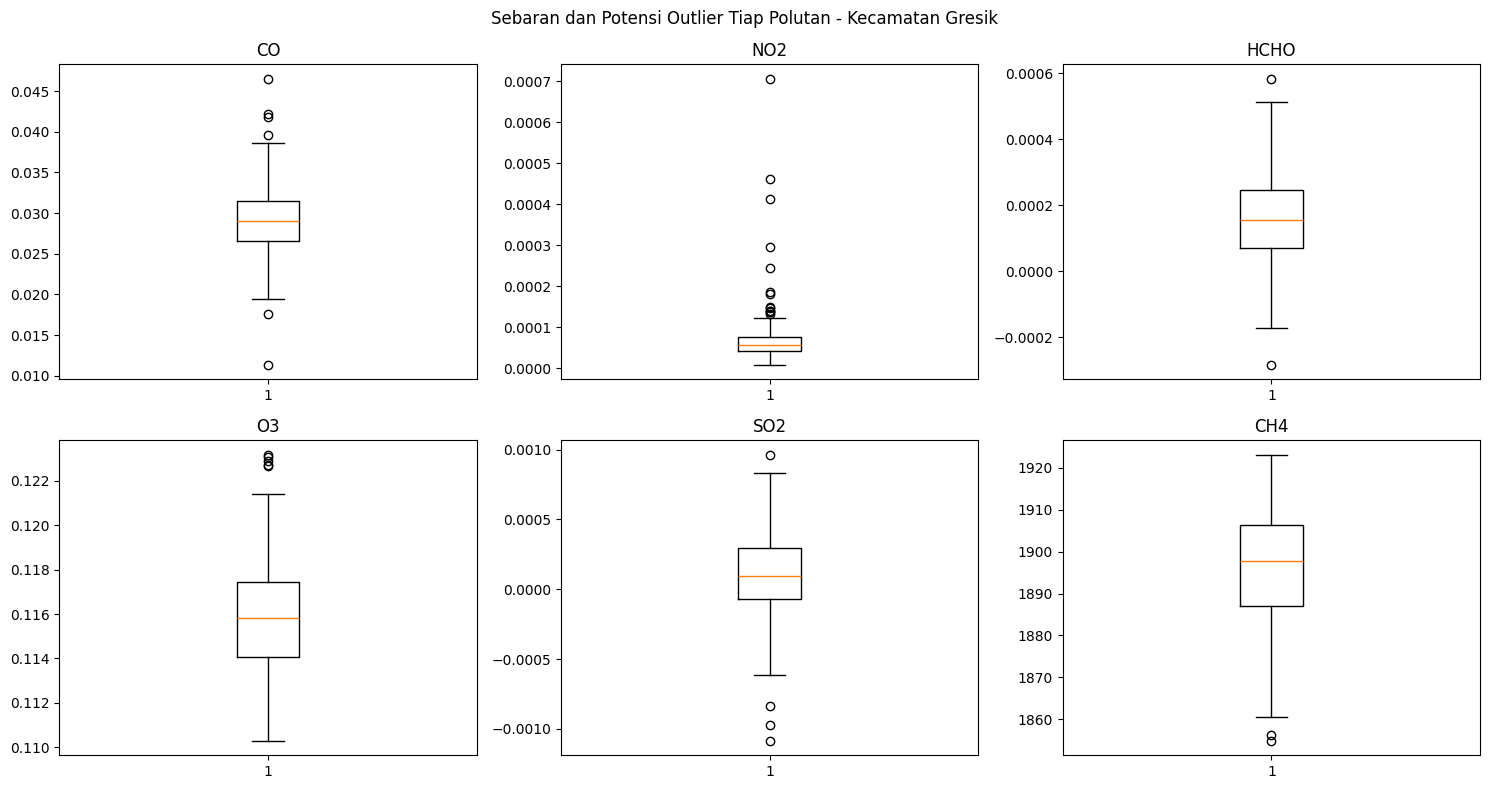

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, kode in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df[kode].dropna())
    ax.set_title(kode)

fig.suptitle("Sebaran dan Potensi Outlier Tiap Polutan - Kecamatan Gresik")
plt.tight_layout()
plt.show()

**Penjelasan kode:** `plt.subplots(2, 3, ...)` membuat 6 area gambar (2 baris × 3 kolom) sekaligus, satu untuk tiap polutan. Perulangan `zip(axes.flatten(), daftar_polutan)` memasangkan tiap area gambar dengan satu polutan, lalu `ax.boxplot(...)` menggambarkan sebaran nilainya — kotak menunjukkan rentang kuartil, garis tengah menunjukkan median, dan titik-titik di luar whisker menandakan kandidat outlier.

Beberapa nilai SO2 dan HCHO tercatat sedikit negatif. Secara fisis, konsentrasi gas tidak mungkin bernilai negatif — kondisi ini muncul karena *noise* pada proses retrieval satelit ketika konsentrasi sebenarnya sangat rendah/mendekati nol, dan cukup umum dijumpai pada data Sentinel-5P. Nilai tersebut tetap dipertahankan pada tahap ini, tidak diperlakukan sebagai kesalahan input.

### 2.7 Grafik Time Series

Dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 agar keenam polutan (dengan satuan dan skala berbeda) dapat dibandingkan pada satu sumbu, serta grafik terpisah per polutan dengan skala aslinya.

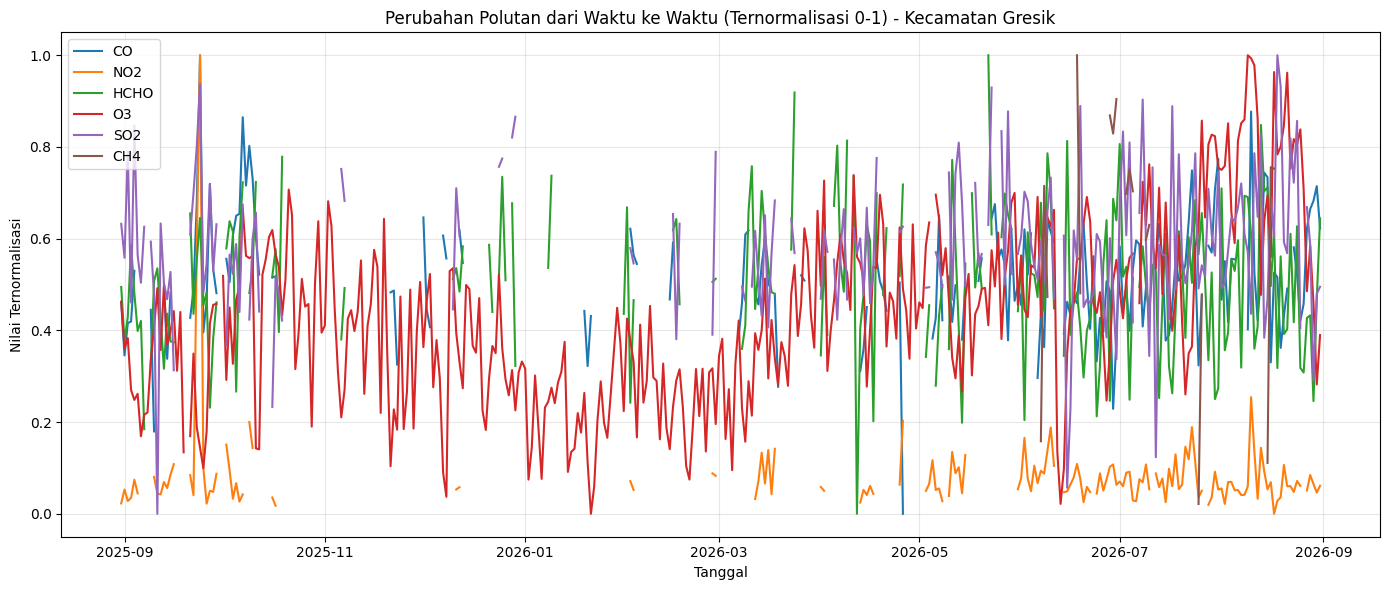

In [16]:
df_norm = df[daftar_polutan].apply(lambda kolom: (kolom - kolom.min()) / (kolom.max() - kolom.min()))

plt.figure(figsize=(14, 6))
for kode in daftar_polutan:
    plt.plot(df["date"], df_norm[kode], label=kode)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1) - Kecamatan Gresik")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan kode:** `df[daftar_polutan].apply(lambda kolom: ...)` menerapkan normalisasi *min-max* ke tiap kolom polutan secara terpisah, sehingga seluruh nilai dipetakan ke rentang 0-1 berdasarkan nilai minimum dan maksimumnya masing-masing. Dengan skala yang seragam ini, keenam polutan — yang aslinya punya satuan dan rentang nilai sangat berbeda — bisa digambar dalam satu grafik garis yang sama untuk melihat pola kenaikan/penurunannya secara relatif.

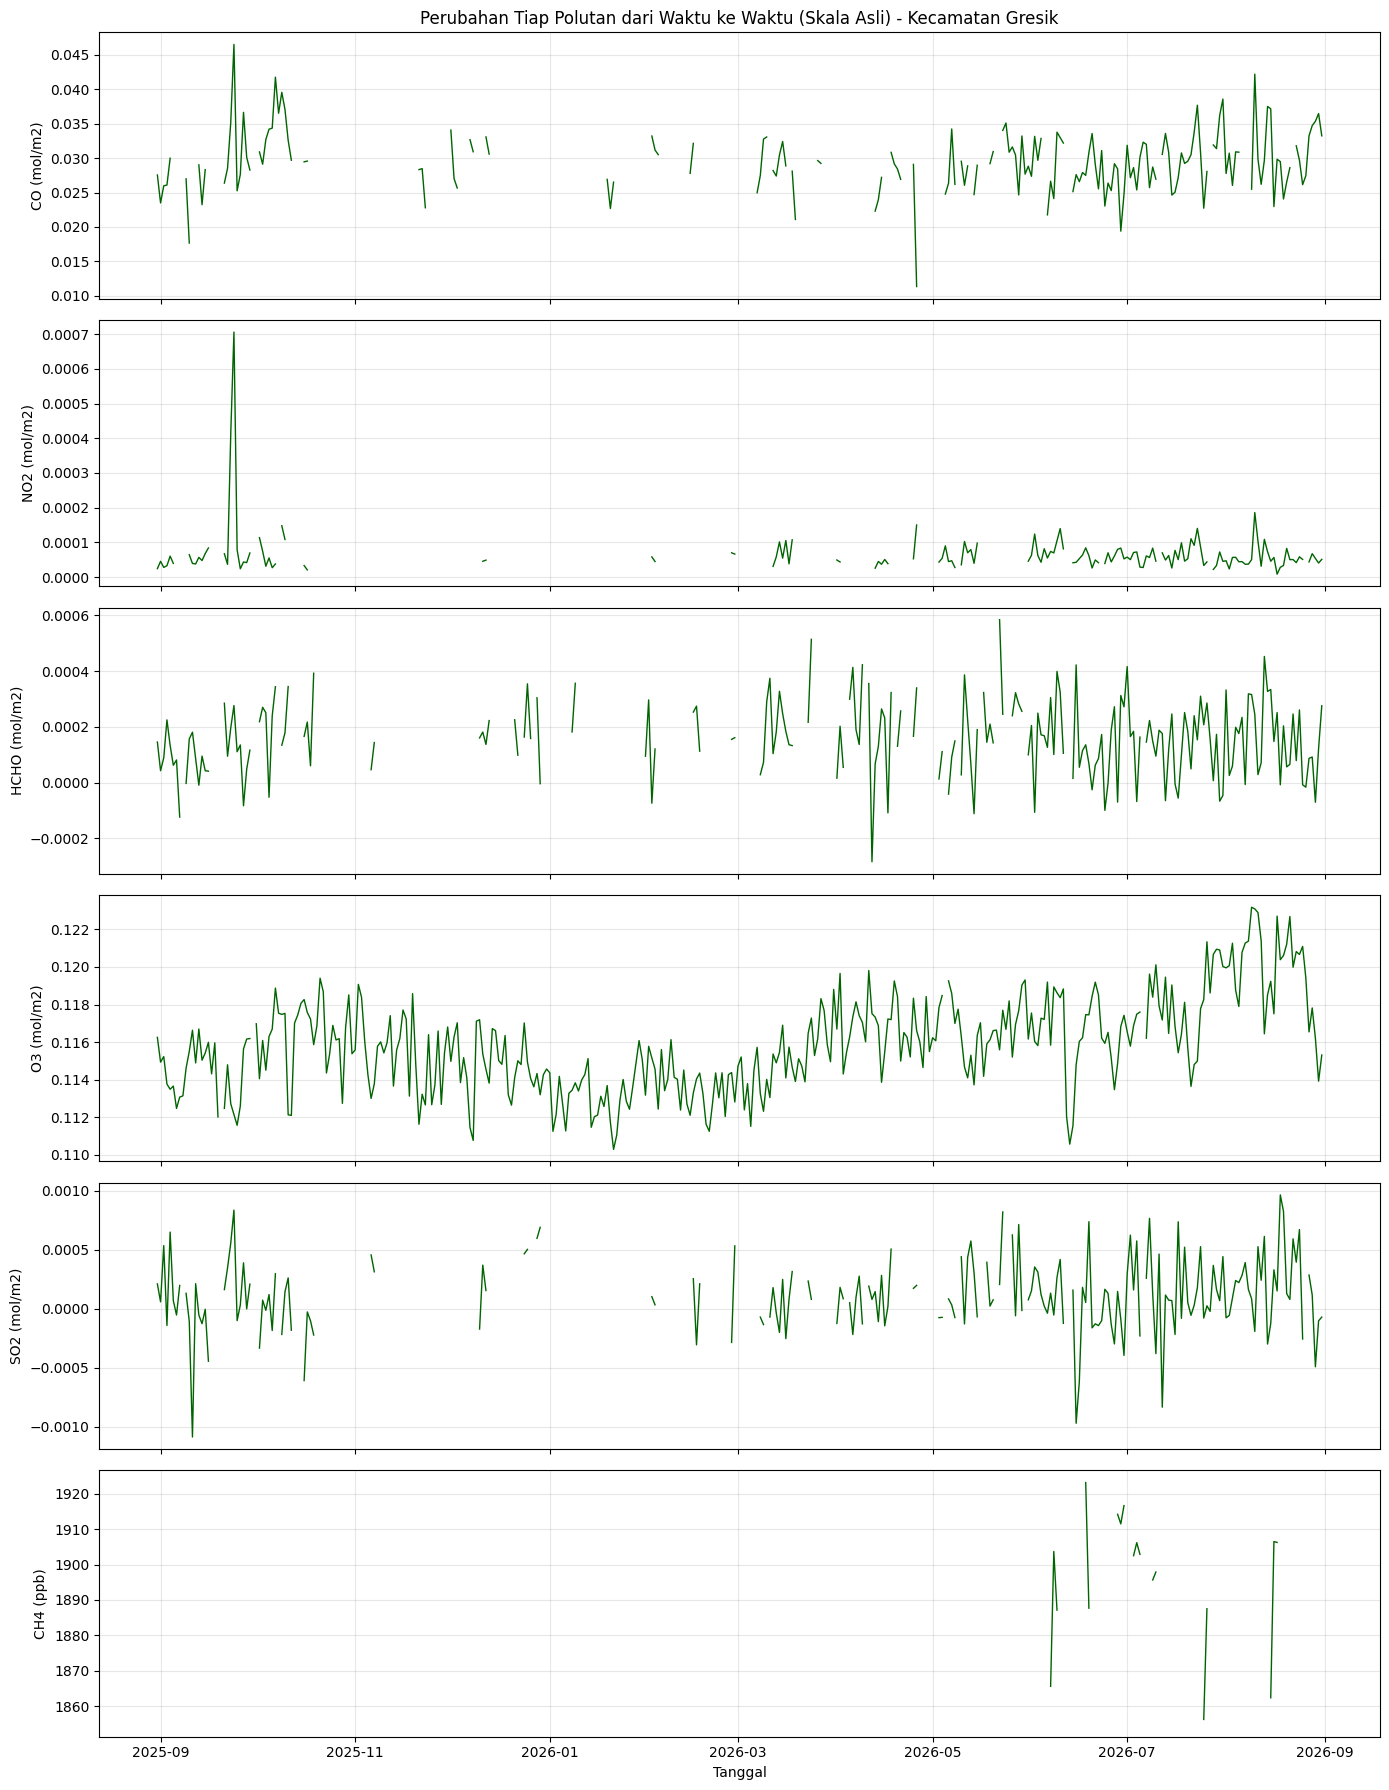

In [17]:
fig, axes = plt.subplots(len(daftar_polutan), 1, figsize=(14, 3 * len(daftar_polutan)), sharex=True)

for ax, kode in zip(axes, daftar_polutan):
    ax.plot(df["date"], df[kode], linewidth=1, color="darkgreen")
    ax.set_ylabel(f"{kode} (ppb)" if kode == "CH4" else f"{kode} (mol/m2)")
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu (Skala Asli) - Kecamatan Gresik")
axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

**Penjelasan kode:** Berbeda dari grafik sebelumnya, di sini dibuat satu area gambar tersendiri untuk tiap polutan (`plt.subplots(len(daftar_polutan), 1, ..., sharex=True)`) menggunakan nilai aslinya (tanpa normalisasi). Pendekatan ini dipakai agar polutan dengan rentang nilai sangat kecil (seperti NO2 atau SO2) maupun sangat besar (CH4) tetap terlihat jelas polanya, karena tidak "tenggelam" oleh skala polutan lain seperti yang berpotensi terjadi pada grafik gabungan.

### 2.8 Menyimpan Data CSV ke Database Aiven PostgreSQL

Data hasil crawling yang telah disimpan dalam file polutan_gresik_timeseries.csv selanjutnya dimasukkan ke database Aiven PostgreSQL menggunakan Google Colab. Proses ini dilakukan dengan membaca file CSV menggunakan Pandas, kemudian membuat koneksi ke database Aiven PostgreSQL menggunakan SQLAlchemy. Setelah koneksi berhasil, data dimasukkan ke dalam tabel

In [18]:
# membaca ulang CSV pollutant_data_gresik.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("polutan_gresik_timeseries.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_gresik", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_gresik" LIMIT 5', engine))

Berhasil! 366 baris terupload ke Aiven.
         date        CO       NO2      HCHO        O3       SO2   CH4
0  2025-08-31  0.027550  0.000024  0.000145  0.116252  0.000210  None
1  2025-09-01  0.023488  0.000045  0.000042  0.114932  0.000058  None
2  2025-09-02  0.025977  0.000028  0.000089  0.115227  0.000534  None
3  2025-09-03  0.026092  0.000033  0.000225  0.113764 -0.000142  None
4  2025-09-04  0.029989  0.000060  0.000133  0.113487  0.000649  None


**Penjelasan kode:** pd.read_csv() membaca file polutan_gresik_timeseries.csv, kemudian userdata.get() mengambil informasi koneksi Aiven yang disimpan sebagai Secret di Google Colab. create_engine() membuat koneksi ke PostgreSQL Aiven, sedangkan to_sql() mengunggah data ke tabel Polutan_gresik. Setelah itu, pd.read_sql() digunakan untuk menampilkan lima data pertama dari tabel sebagai pengecekan bahwa data berhasil tersimpan.

### 2.9 Menghubungkan Database PostgreSQL Aiven dengan KNIME

Data yang telah disimpan pada database PostgreSQL Aiven selanjutnya diakses menggunakan KNIME untuk dilakukan proses pengolahan dan analisis. Pada tahap ini, KNIME dihubungkan dengan database Aiven, kemudian tabel Polutan_gresik dipilih dan datanya dibaca ke dalam workflow. Proses tersebut menggunakan beberapa node yang saling terhubung, yaitu PostgreSQL Connector, DB Table Selector, DB Reader, dan Statistics.

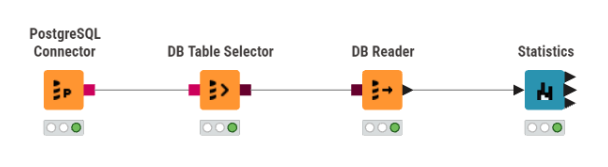

#### 1. PostgreSQL Connector

Node ini digunakan untuk menghubungkan KNIME dengan database PostgreSQL yang tersimpan di Aiven. Konfigurasi dilakukan dengan memasukkan hostname, port, nama database, username, dan password sesuai informasi koneksi Aiven.

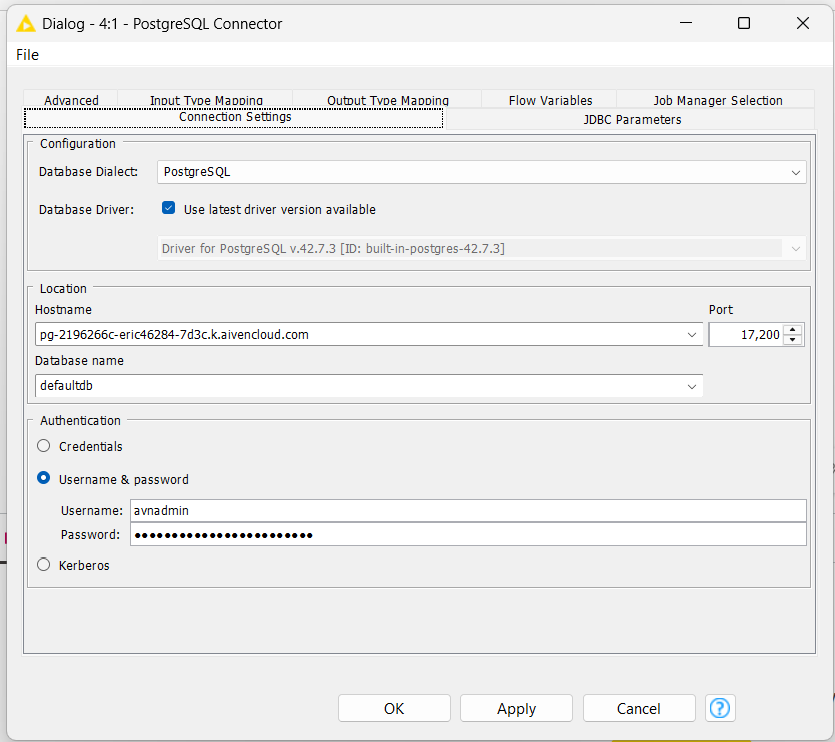

#### 2. DB Table Selector
Node ini digunakan untuk memilih tabel Polutan_gresik pada schema public yang akan digunakan dalam proses pengolahan data di KNIME.

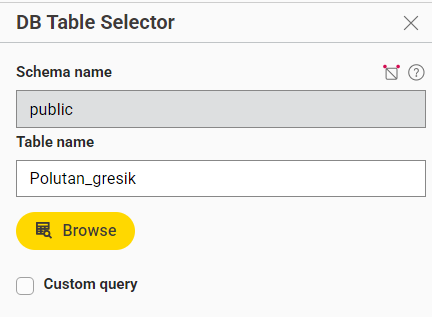

#### 3. DB Reader
Node ini digunakan untuk membaca dan mengambil data dari tabel Polutan_gresik yang telah dipilih sebelumnya, sehingga data dapat digunakan untuk proses analisis di KNIME.

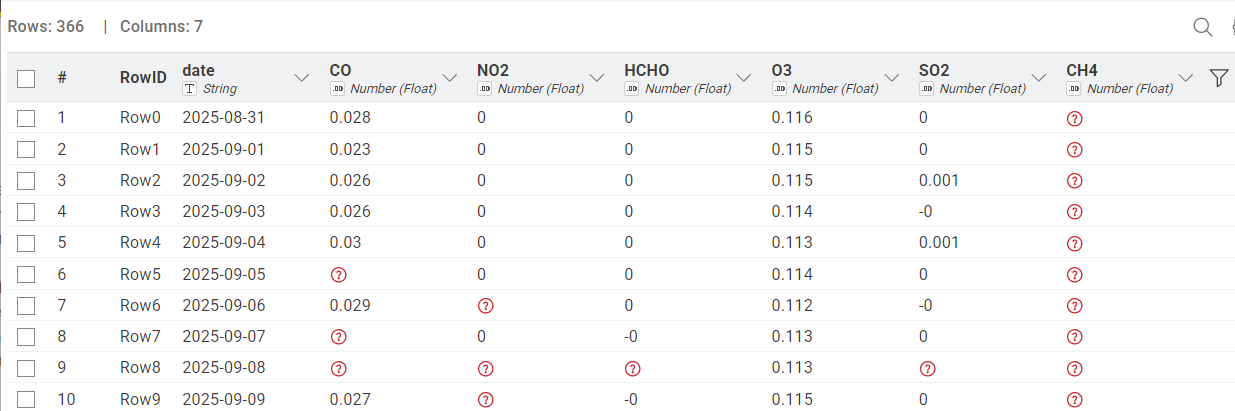

#### 4. Statistics
Node ini digunakan untuk menganalisis data dari setiap polutan dan menghasilkan ringkasan statistik. Hasil analisis terdiri dari beberapa kolom, yaitu:

1. **Min** - menunjukkan nilai terendah yang terdapat pada setiap kolom polutan.
2. **Max** - menunjukkan nilai tertinggi yang terdapat pada setiap kolom polutan.
3. **Mean** - menunjukkan nilai rata-rata dari seluruh data pada kolom polutan.
4. **Std. deviation** - menunjukkan standar deviasi, yaitu ukuran penyebaran data dari nilai rata-ratanya.
5. **Variance** - menunjukkan varians, yaitu ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.
6. **Skewness** - menunjukkan tingkat kemiringan distribusi data. Nilai positif menunjukkan distribusi cenderung miring ke kanan, sedangkan nilai negatif menunjukkan kecenderungan miring ke kiri.
7. **Kurtosis** - menunjukkan tingkat keruncingan atau bentuk distribusi data dibandingkan dengan distribusi normal.
8. **Overall sum** - menunjukkan jumlah keseluruhan nilai pada setiap kolom polutan.
9. **No. missing** - menunjukkan jumlah data yang kosong atau *missing* pada setiap kolom.
10. **No. NaNs** - menunjukkan jumlah data yang bernilai NaN (*Not a Number*) pada setiap kolom.
11. **No. +oos** - menunjukkan jumlah data yang memiliki nilai positif tak hingga (+oo).
12. **No. -oos** - menunjukkan jumlah data yang memiliki nilai negatif tak hingga (-oo).
13. **Median** - menunjukkan nilai tengah dari seluruh data setelah data diurutkan.
14. **Row count** - menunjukkan jumlah baris data yang dianalisis. Pada hasil tersebut terdapat 366 baris untuk setiap polutan.
15. **Histogram** - menampilkan distribusi nilai data dalam bentuk grafik histogram sehingga dapat dilihat pola penyebaran nilai pada setiap polutan.

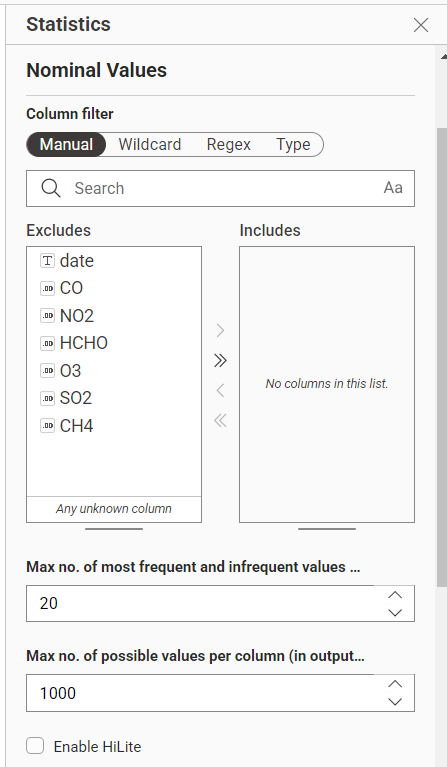

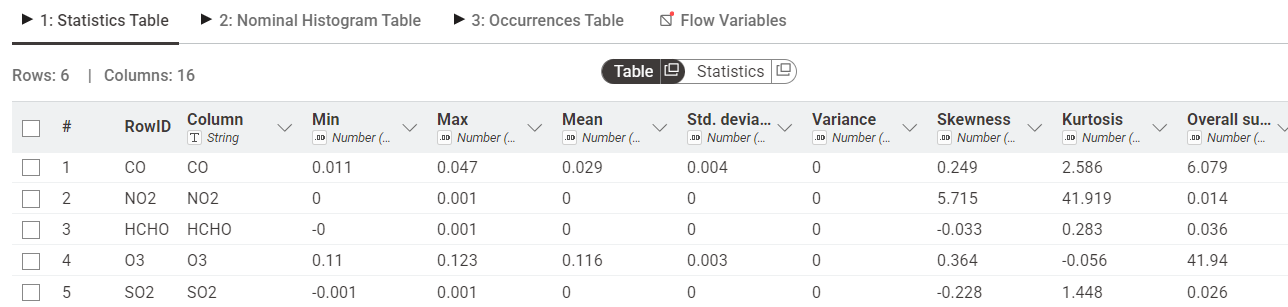

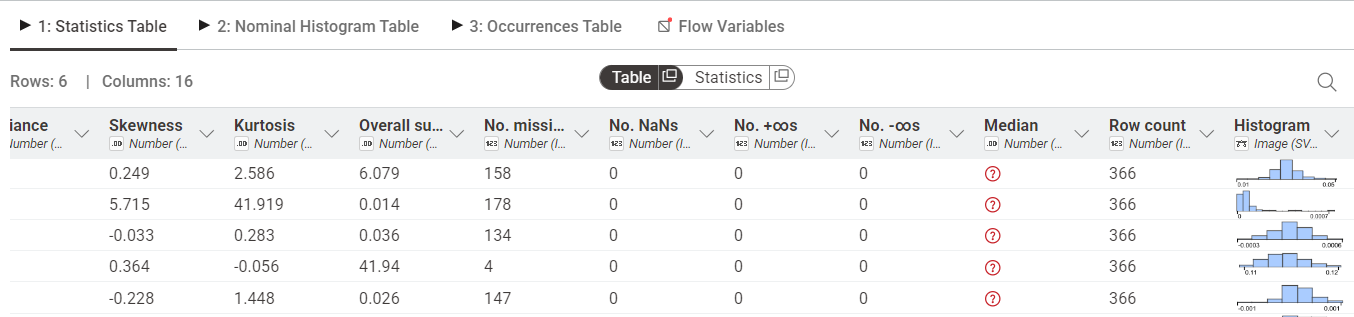

### 2.10 Contoh Perhitungan Statistics Manual

Sebagai contoh, perhitungan dilakukan menggunakan 5 data polutan **CO**, yaitu **0,028; 0,023; 0,026; 0,026; dan 0,030**.

#### **1. Min**

Nilai minimum merupakan nilai terkecil dari seluruh data.

$$
\text{Min} = \min(x)
$$

$$
\text{Min} = 0,023
$$

**Hasil: Min = 0,023**

#### **2. Max**

Nilai maksimum merupakan nilai terbesar dari seluruh data.

$$
\text{Max} = \max(x)
$$

$$
\text{Max} = 0,030
$$

**Hasil: Max = 0,030**

#### **3. Mean**

Mean merupakan nilai rata-rata dari seluruh data.

$$
\bar{x} = \frac{\sum x}{n}
$$

$$
\bar{x} =
\frac{0,028+0,023+0,026+0,026+0,030}{5}
$$

$$
= \frac{0,133}{5}
= 0,0266
$$

**Hasil: Mean = 0,0266**

#### **4. Std. Deviation**

Standar deviasi menunjukkan tingkat penyebaran data terhadap nilai rata-rata.

$$
s = \sqrt{\frac{\sum(x-\bar{x})^2}{n}}
$$

$$
s =
\sqrt{
\frac{
(0,028-0,0266)^2+
(0,023-0,0266)^2+
(0,026-0,0266)^2+
(0,026-0,0266)^2+
(0,030-0,0266)^2
}{5}
}
$$

$$
s = \sqrt{0,00000544}
\approx 0,00233
$$

**Hasil: Std. Deviation ≈ 0,00233**

#### **5. Variance**

Variance merupakan ukuran penyebaran data yang diperoleh dari kuadrat standar deviasi.

$$
s^2 = \frac{\sum(x-\bar{x})^2}{n}
$$

$$
s^2 = 0,00000544
$$

**Hasil: Variance = 0,00000544**

#### **6. Skewness**

Skewness menunjukkan tingkat kemiringan distribusi data terhadap nilai rata-ratanya.

$$
\text{Skewness}
=
\frac{1}{n}
\sum
\left(\frac{x-\bar{x}}{s}\right)^3
$$

Dengan menggunakan nilai rata-rata $0,0266$ dan standar deviasi sekitar $0,00233$, diperoleh:

$$
\text{Skewness} \approx -0,079
$$

**Hasil: Skewness ≈ -0,079**

#### **7. Kurtosis**

Kurtosis menunjukkan tingkat keruncingan atau bentuk distribusi data.

$$
\text{Kurtosis}
=
\frac{1}{n}
\sum
\left(\frac{x-\bar{x}}{s}\right)^4
-3
$$

Berdasarkan perhitungan kelima data tersebut:

$$
\text{Kurtosis} \approx -0,934
$$

**Hasil: Kurtosis ≈ -0,934**

#### **8. Overall Sum**

Overall sum merupakan jumlah seluruh nilai data.

$$
\sum x
=
0,028+0,023+0,026+0,026+0,030
$$

$$
\sum x = 0,133
$$

**Hasil: Overall Sum = 0,133**

#### **9. No. Missing**

No. missing menunjukkan jumlah data yang kosong atau tidak memiliki nilai.

Pada contoh terdapat 5 data dan semuanya memiliki nilai.

$$
\text{No. Missing} = 0
$$

**Hasil: No. Missing = 0**

#### **10. No. NaNs**

No. NaNs menunjukkan jumlah data yang memiliki nilai **NaN (Not a Number)**.

Pada contoh tidak terdapat nilai NaN.

$$
\text{No. NaNs} = 0
$$

**Hasil: No. NaNs = 0**

#### **11. No. +oos**

No. +oos menunjukkan jumlah data yang memiliki nilai positif tak hingga (+oo).

Pada contoh tidak terdapat nilai +oo.

$$
\text{No. +oos} = 0
$$

**Hasil: No. +oos = 0**

#### **12. No. -oos**

No. -oos menunjukkan jumlah data yang memiliki nilai negatif tak hingga (-oo).

Pada contoh tidak terdapat nilai -oo.

$$
\text{No. -oos} = 0
$$

**Hasil: No. -oos = 0**

#### **13. Median**

Median merupakan nilai tengah setelah data diurutkan.

Data setelah diurutkan:

$$
0,023;\ 0,026;\ \mathbf{0,026};\ 0,028;\ 0,030
$$

$$
\text{Median} = 0,026
$$

**Hasil: Median = 0,026**

#### **14. Row Count**

Row count menunjukkan jumlah baris atau jumlah data yang dianalisis.

$$
\text{Row Count} = n = 5
$$

**Hasil: Row Count = 5**

## 3. Data Preparation



### 3.1 Feature Extraction Menggunakan TSFEL

Feature extraction dilakukan untuk mengambil berbagai karakteristik dari data polutan **NO2**. Proses ini menggunakan library **TSFEL (Time Series Feature Extraction Library)**. Sebelum ekstraksi dilakukan, data terlebih dahulu diperiksa dan dibersihkan dari nilai kosong serta outlier. Nilai kosong kemudian diisi menggunakan interpolasi berdasarkan waktu.

Setelah data siap, TSFEL digunakan untuk menghitung **68 fitur** dari data NO2. Fitur yang dihasilkan meliputi statistik dasar, karakteristik sinyal, spektral, dan beberapa fitur lainnya. Hasil ekstraksi kemudian disimpan dalam bentuk CSV untuk digunakan pada proses selanjutnya.

In [ ]:
!pip install tsfel

**Penjelasan kode:** `!pip install tsfel` digunakan untuk memasang library TSFEL pada Google Colab agar dapat digunakan untuk proses feature extraction data polutan.

In [24]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('polutan_gresik_timeseries.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Gresik_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 178
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


**Penjelasan kode:** Kode digunakan untuk membaca data NO2, mengubah format tanggal, serta memastikan nilai polutan dalam bentuk numerik. Data kemudian diperiksa untuk menemukan outlier menggunakan metode IQR dan nilai kosong diisi dengan interpolasi berdasarkan waktu. Setelah data bersih, TSFEL digunakan untuk menghitung 68 fitur yang telah ditentukan. Hasilnya disimpan dalam DataFrame dan diekspor ke file CSV.

**Pengelompokan Fitur TSFEL**

Fitur yang dihasilkan menggunakan TSFEL terdiri dari beberapa kelompok berdasarkan karakteristik yang dihitung. Pengelompokan 68 fitur yang digunakan dapat dilihat pada tabel berikut.

#### A. Statistical Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `calc_max` | Menentukan nilai maksimum dari data. |
| 2 | `calc_mean` | Menghitung nilai rata-rata data. |
| 3 | `calc_median` | Menentukan nilai tengah data. |
| 4 | `calc_min` | Menentukan nilai minimum dari data. |
| 5 | `calc_std` | Mengukur penyebaran data terhadap rata-rata. |
| 6 | `calc_var` | Mengukur variasi atau penyebaran data. |
| 7 | `kurtosis` | Mengukur tingkat keruncingan distribusi data. |
| 8 | `skewness` | Mengukur tingkat kemiringan distribusi data. |
| 9 | `interq_range` | Mengukur rentang antara kuartil pertama dan ketiga. |
| 10 | `mean_abs_deviation` | Mengukur rata-rata penyimpangan absolut dari rata-rata. |
| 11 | `median_abs_deviation` | Mengukur penyimpangan absolut berdasarkan median. |
| 12 | `hist_mode` | Menentukan nilai yang paling sering muncul. |
| 13 | `rms` | Mengukur besar sinyal berdasarkan akar rata-rata kuadrat. |
| 14 | `mse` | Mengukur rata-rata kuadrat perbedaan nilai. |

#### B. Temporal Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `autocorr` | Mengukur hubungan antara nilai dengan nilai sebelumnya. |
| 2 | `mean_abs_diff` | Menghitung rata-rata perubahan absolut antar nilai. |
| 3 | `mean_diff` | Menghitung rata-rata perubahan antar nilai. |
| 4 | `median_abs_diff` | Menentukan median perubahan absolut antar nilai. |
| 5 | `median_diff` | Menentukan median perubahan antar nilai. |
| 6 | `sum_abs_diff` | Menghitung jumlah perubahan absolut antar nilai. |
| 7 | `negative_turning` | Menghitung perubahan arah negatif pada sinyal. |
| 8 | `positive_turning` | Menghitung perubahan arah positif pada sinyal. |
| 9 | `zero_cross` | Menghitung jumlah perubahan sinyal yang melewati nilai nol. |
| 10 | `slope` | Mengukur kecenderungan naik atau turun pada data. |
| 11 | `distance` | Mengukur perubahan atau jarak antar nilai pada sinyal. |
| 12 | `neighbourhood_peaks` | Mengidentifikasi jumlah puncak lokal pada sinyal. |
| 13 | `pk_pk_distance` | Mengukur jarak antara nilai puncak dan lembah sinyal. |

#### C. Spectral Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `fundamental_frequency` | Menentukan frekuensi dasar sinyal. |
| 2 | `max_frequency` | Menentukan frekuensi dengan komponen paling tinggi. |
| 3 | `max_power_spectrum` | Menentukan daya spektrum terbesar. |
| 4 | `median_frequency` | Menentukan frekuensi yang membagi energi spektrum menjadi dua bagian. |
| 5 | `power_bandwidth` | Mengukur rentang frekuensi yang memiliki sebagian besar energi. |
| 6 | `spectral_centroid` | Menentukan pusat distribusi energi pada spektrum. |
| 7 | `spectral_decrease` | Mengukur penurunan energi pada spektrum. |
| 8 | `spectral_distance` | Mengukur perbedaan karakteristik spektrum. |
| 9 | `spectral_entropy` | Mengukur ketidakaturan distribusi energi spektrum. |
| 10 | `spectral_kurtosis` | Mengukur keruncingan distribusi energi spektrum. |
| 11 | `spectral_positive_turning` | Menghitung perubahan arah positif pada spektrum. |
| 12 | `spectral_roll_off` | Menentukan batas frekuensi yang mencakup sebagian besar energi. |
| 13 | `spectral_roll_on` | Menentukan awal peningkatan energi spektrum. |
| 14 | `spectral_skewness` | Mengukur kemiringan distribusi energi spektrum. |
| 15 | `spectral_slope` | Mengukur kecenderungan naik atau turun pada spektrum. |
| 16 | `spectral_spread` | Mengukur penyebaran energi di sekitar pusat spektrum. |
| 17 | `spectral_variation` | Mengukur perubahan karakteristik spektrum. |
| 18 | `spectrogram_mean_coeff` | Menghitung rata-rata koefisien pada spectrogram. |

#### D. Fractal Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `dfa` | Mengukur pola fluktuasi jangka panjang pada data. |
| 2 | `higuchi_fractal_dimension` | Mengukur kompleksitas pola sinyal. |
| 3 | `hurst_exponent` | Menggambarkan kecenderungan pola data terhadap pola sebelumnya. |
| 4 | `maximum_fractal_length` | Mengukur panjang maksimum pola fraktal. |
| 5 | `petrosian_fractal_dimension` | Mengukur kompleksitas sinyal berdasarkan perubahan arah. |

#### E. Cepstral Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `lpcc` | Menghasilkan karakteristik sinyal berdasarkan Linear Prediction Cepstral Coefficients. |
| 2 | `mfcc` | Menghasilkan karakteristik sinyal berdasarkan Mel-Frequency Cepstral Coefficients. |

#### F. Wavelet Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `wavelet_abs_mean` | Menghitung rata-rata absolut koefisien wavelet. |
| 2 | `wavelet_energy` | Mengukur energi berdasarkan koefisien wavelet. |
| 3 | `wavelet_entropy` | Mengukur tingkat ketidakaturan energi wavelet. |
| 4 | `wavelet_std` | Mengukur penyebaran koefisien wavelet. |
| 5 | `wavelet_var` | Mengukur variasi koefisien wavelet. |

#### G. Distribution and Complexity Features

| No. | Fitur | Penjelasan |
|---|---|---|
| 1 | `abs_energy` | Mengukur total energi berdasarkan kuadrat nilai data. |
| 2 | `average_power` | Mengukur rata-rata kekuatan atau energi sinyal. |
| 3 | `auc` | Menghitung luas area di bawah kurva. |
| 4 | `calc_centroid` | Menentukan titik pusat distribusi data. |
| 5 | `ecdf` | Menggambarkan distribusi kumulatif data. |
| 6 | `ecdf_percentile` | Menentukan posisi nilai berdasarkan persentil. |
| 7 | `ecdf_percentile_count` | Menghitung jumlah data pada persentil tertentu. |
| 8 | `ecdf_slope` | Mengukur kemiringan distribusi kumulatif. |
| 9 | `entropy` | Mengukur tingkat ketidakpastian atau keragaman data. |
| 10 | `human_range_energy` | Mengukur energi sinyal pada rentang frekuensi tertentu. |
| 11 | `lempel_ziv` | Mengukur kompleksitas pola pada sinyal. |